# Feature Analysis & Selection

Đánh giá features bằng các phương pháp thống kê:
1. **Cohen's d** - Effect size
2. **KS Statistic** - Kolmogorov-Smirnov test
3. **T-test p-value** - Statistical significance

Sau đó chọn features tốt nhất và tạo dataset final.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries loaded!")

Libraries loaded!


## 1. Load Data

In [46]:
# Paths
BASE_DIR = Path("../..")
DATA_DIR = BASE_DIR / "data" / "processed"
OUTPUT_DATA_DIR = BASE_DIR / "data" / "processed"    # CSV cho training
OUTPUT_ANALYSIS_DIR = BASE_DIR / "data" / "analysis" # Thống kê
OUTPUT_FIGURES_DIR = BASE_DIR / "data" / "figures"   # Biểu đồ

# Create output directories if not exist
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load processed data
df = pd.read_csv(DATA_DIR / "01_preprocessed.csv")
print(f"Loaded: {len(df)} rows, {len(df.columns)} columns")
print(f"\nLabel distribution:")
print(df['label'].value_counts())

Loaded: 4736 rows, 64 columns

Label distribution:
label
0    3929
1     807
Name: count, dtype: int64


In [47]:
# Get feature columns (columns starting with 'feat_')
feature_cols = [col for col in df.columns if col.startswith('feat_')]

# Get numeric features only
numeric_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

print(f"Total features: {len(feature_cols)}")
print(f"Numeric features: {len(numeric_features)}")
print("\nFeature list:")
for i, feat in enumerate(numeric_features, 1):
    print(f"  {i}. {feat}")

Total features: 36
Numeric features: 35

Feature list:
  1. feat_num_chars
  2. feat_num_words
  3. feat_num_sentences
  4. feat_num_exclamation
  5. feat_num_question
  6. feat_num_uppercase_words
  7. feat_uppercase_ratio
  8. feat_num_emojis
  9. feat_num_urls
  10. feat_num_hashtags
  11. feat_num_mentions
  12. feat_num_digits
  13. feat_digit_ratio
  14. feat_num_special_chars
  15. feat_avg_word_length
  16. feat_num_long_words
  17. feat_num_short_words
  18. feat_num_quoted
  19. feat_has_all_caps
  20. feat_num_repeated_chars
  21. feat_num_newlines
  22. feat_punctuation_ratio
  23. feat_engagement_total
  24. feat_like_per_char
  25. feat_cmt_per_char
  26. feat_share_per_char
  27. feat_like_cmt_ratio
  28. feat_share_like_ratio
  29. feat_fake_ratio
  30. feat_real_ratio
  31. feat_is_weekend
  32. feat_is_night
  33. feat_is_morning
  34. feat_is_afternoon
  35. feat_is_evening


In [48]:
# Separate data by label
df_real = df[df['label'] == 0]  # Real news
df_fake = df[df['label'] == 1]  # Fake news

print(f"Real news: {len(df_real)} samples")
print(f"Fake news: {len(df_fake)} samples")

Real news: 3929 samples
Fake news: 807 samples


## 2. Statistical Tests Functions

In [49]:
def cohens_d(group1, group2):
    """
    Calculate Cohen's d effect size
    
    Interpretation:
    - |d| < 0.2: negligible
    - 0.2 <= |d| < 0.5: small
    - 0.5 <= |d| < 0.8: medium
    - |d| >= 0.8: large
    """
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    
    # Pooled standard deviation
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    
    if pooled_std == 0:
        return 0
    
    d = (group1.mean() - group2.mean()) / pooled_std
    return d


def interpret_cohens_d(d):
    """Interpret Cohen's d value"""
    d = abs(d)
    if d < 0.2:
        return "negligible"
    elif d < 0.5:
        return "small"
    elif d < 0.8:
        return "medium"
    else:
        return "large"


def ks_test(group1, group2):
    """
    Kolmogorov-Smirnov test
    Returns: (KS statistic, p-value)
    
    Higher KS statistic = more different distributions
    """
    statistic, pvalue = stats.ks_2samp(group1, group2)
    return statistic, pvalue


def ttest(group1, group2):
    """
    Independent samples t-test
    Returns: (t-statistic, p-value)
    
    p < 0.05 = statistically significant difference
    """
    statistic, pvalue = stats.ttest_ind(group1, group2, equal_var=False)
    return statistic, pvalue


print("Statistical functions defined!")

Statistical functions defined!


## 3. Calculate Statistics for All Features

In [50]:
# Calculate all statistics
results = []

for feat in numeric_features:
    real_values = df_real[feat].dropna()
    fake_values = df_fake[feat].dropna()
    
    # Cohen's d
    d = cohens_d(fake_values, real_values)  # Fake - Real
    
    # KS test
    ks_stat, ks_pval = ks_test(real_values, fake_values)
    
    # T-test
    t_stat, t_pval = ttest(real_values, fake_values)
    
    results.append({
        'feature': feat,
        'mean_real': real_values.mean(),
        'mean_fake': fake_values.mean(),
        'std_real': real_values.std(),
        'std_fake': fake_values.std(),
        'cohens_d': d,
        'cohens_d_abs': abs(d),
        'cohens_d_interp': interpret_cohens_d(d),
        'ks_statistic': ks_stat,
        'ks_pvalue': ks_pval,
        't_statistic': t_stat,
        't_pvalue': t_pval,
        'significant': t_pval < 0.05
    })

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('cohens_d_abs', ascending=False)

print("Statistics calculated!")
print(f"\nTotal features analyzed: {len(results_df)}")

Statistics calculated!

Total features analyzed: 35


In [51]:
# Display results table
display_cols = ['feature', 'mean_real', 'mean_fake', 'cohens_d', 'cohens_d_interp', 
                'ks_statistic', 't_pvalue', 'significant']

print("="*100)
print("FEATURE STATISTICS (sorted by |Cohen's d|)")
print("="*100)

# Format for display
display_df = results_df[display_cols].copy()
display_df['mean_real'] = display_df['mean_real'].round(4)
display_df['mean_fake'] = display_df['mean_fake'].round(4)
display_df['cohens_d'] = display_df['cohens_d'].round(4)
display_df['ks_statistic'] = display_df['ks_statistic'].round(4)
display_df['t_pvalue'] = display_df['t_pvalue'].apply(lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}")

display(display_df)

FEATURE STATISTICS (sorted by |Cohen's d|)


,feature,mean_real,mean_fake,cohens_d,cohens_d_interp,ks_statistic,t_pvalue,significant
29,feat_real_ratio,0.9906,0.0464,-11.0239,large,0.9716,0.00e+00,True
28,feat_fake_ratio,0.0094,0.9536,11.0239,large,0.9716,0.00e+00,True
3,feat_num_exclamation,0.1945,0.7683,0.5584,medium,0.2231,1.95e-20,True
14,feat_avg_word_length,4.5101,4.1977,-0.4276,small,0.2456,1.11e-34,True
4,feat_num_question,0.2051,0.6419,0.3922,small,0.1461,1.48e-11,True
34,feat_is_evening,0.1049,0.2169,0.3426,small,0.1120,5.41e-13,True
8,feat_num_urls,0.4355,0.1908,-0.2309,small,0.1179,2.10e-12,True
12,feat_digit_ratio,0.0224,0.0165,-0.2253,small,0.1387,1.38e-10,True
2,feat_num_sentences,6.0725,8.6047,0.2085,small,0.2047,4.40e-07,True
19,feat_num_repeated_chars,0.4469,0.7162,0.1975,negligible,0.1105,2.53e-04,True


## 4. Visualization

### 4.1 Cohen's d Bar Chart

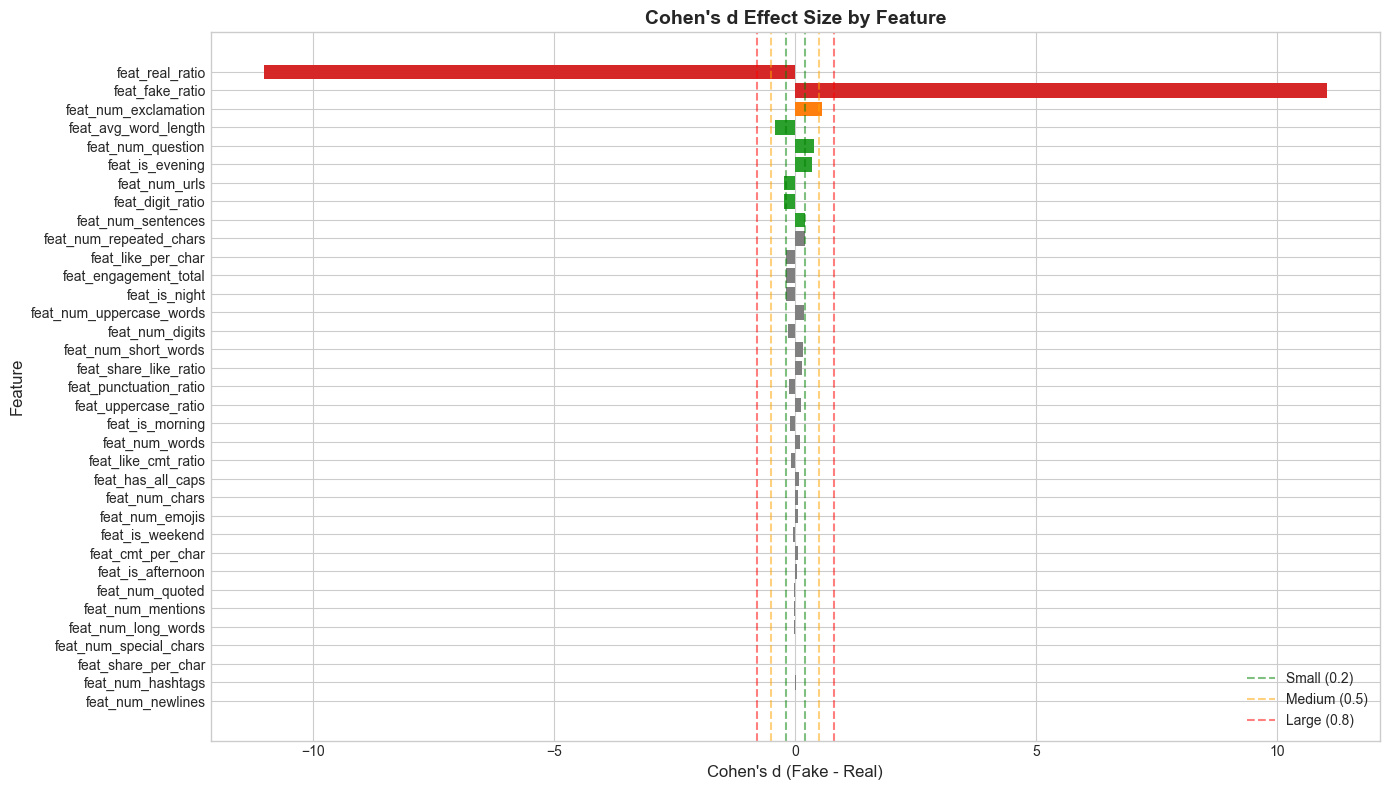


✓ Saved: figures/cohens_d_chart.png


In [52]:
# Cohen's d bar chart
fig, ax = plt.subplots(figsize=(14, 8))

# Sort by absolute Cohen's d
plot_df = results_df.sort_values('cohens_d_abs', ascending=True)

# Color based on effect size
colors = []
for d in plot_df['cohens_d_abs']:
    if d >= 0.8:
        colors.append('#d62728')  # Red - large
    elif d >= 0.5:
        colors.append('#ff7f0e')  # Orange - medium
    elif d >= 0.2:
        colors.append('#2ca02c')  # Green - small
    else:
        colors.append('#7f7f7f')  # Gray - negligible

# Plot
bars = ax.barh(plot_df['feature'], plot_df['cohens_d'], color=colors)

# Add threshold lines
ax.axvline(x=0.2, color='green', linestyle='--', alpha=0.5, label='Small (0.2)')
ax.axvline(x=-0.2, color='green', linestyle='--', alpha=0.5)
ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Medium (0.5)')
ax.axvline(x=-0.5, color='orange', linestyle='--', alpha=0.5)
ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='Large (0.8)')
ax.axvline(x=-0.8, color='red', linestyle='--', alpha=0.5)

ax.set_xlabel("Cohen's d (Fake - Real)", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
ax.set_title("Cohen's d Effect Size by Feature", fontsize=14, fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'cohens_d_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: figures/cohens_d_chart.png")

### 4.2 KS Statistic vs Cohen's d Scatter

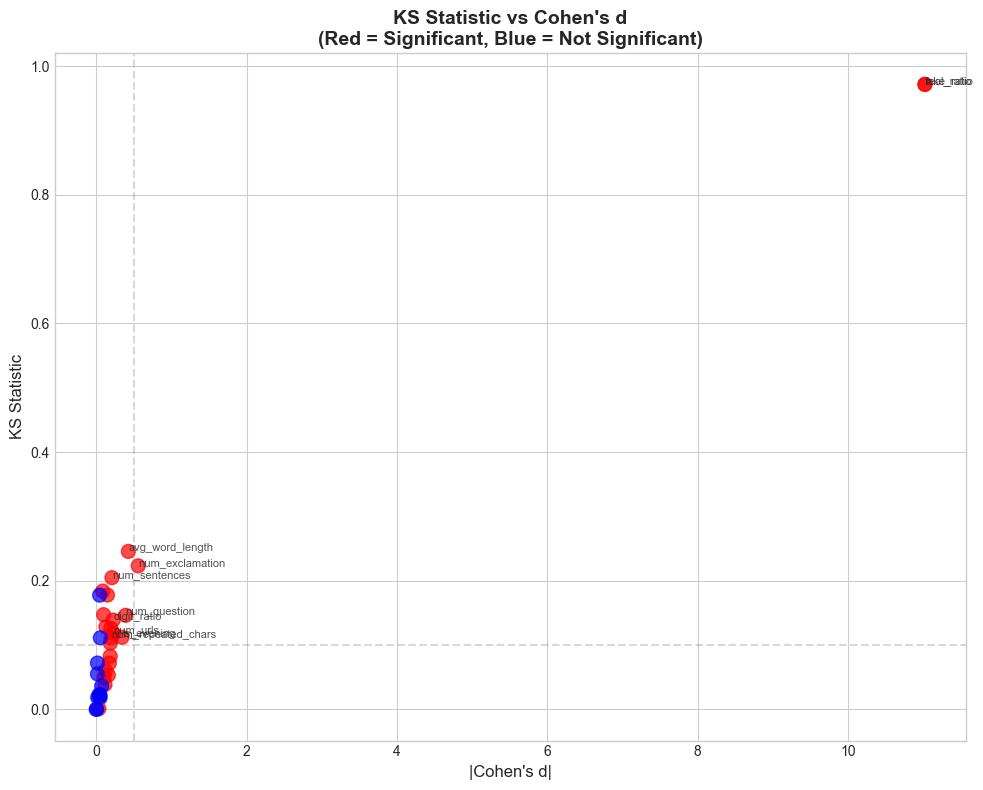


✓ Saved: figures/ks_vs_cohens_d.png


In [53]:
# Scatter plot: KS Statistic vs Cohen's d (absolute)
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(results_df['cohens_d_abs'], results_df['ks_statistic'], 
                     c=results_df['significant'].map({True: 'red', False: 'blue'}),
                     s=100, alpha=0.7)

# Add labels for top features
for idx, row in results_df.head(10).iterrows():
    ax.annotate(row['feature'].replace('feat_', ''), 
                (row['cohens_d_abs'], row['ks_statistic']),
                fontsize=8, alpha=0.8)

ax.set_xlabel("|Cohen's d|", fontsize=12)
ax.set_ylabel("KS Statistic", fontsize=12)
ax.set_title("KS Statistic vs Cohen's d\n(Red = Significant, Blue = Not Significant)", 
             fontsize=14, fontweight='bold')

# Add quadrant lines
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.3)
ax.axhline(y=0.1, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'ks_vs_cohens_d.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: figures/ks_vs_cohens_d.png")

### 4.3 Distribution Plots for Top Features

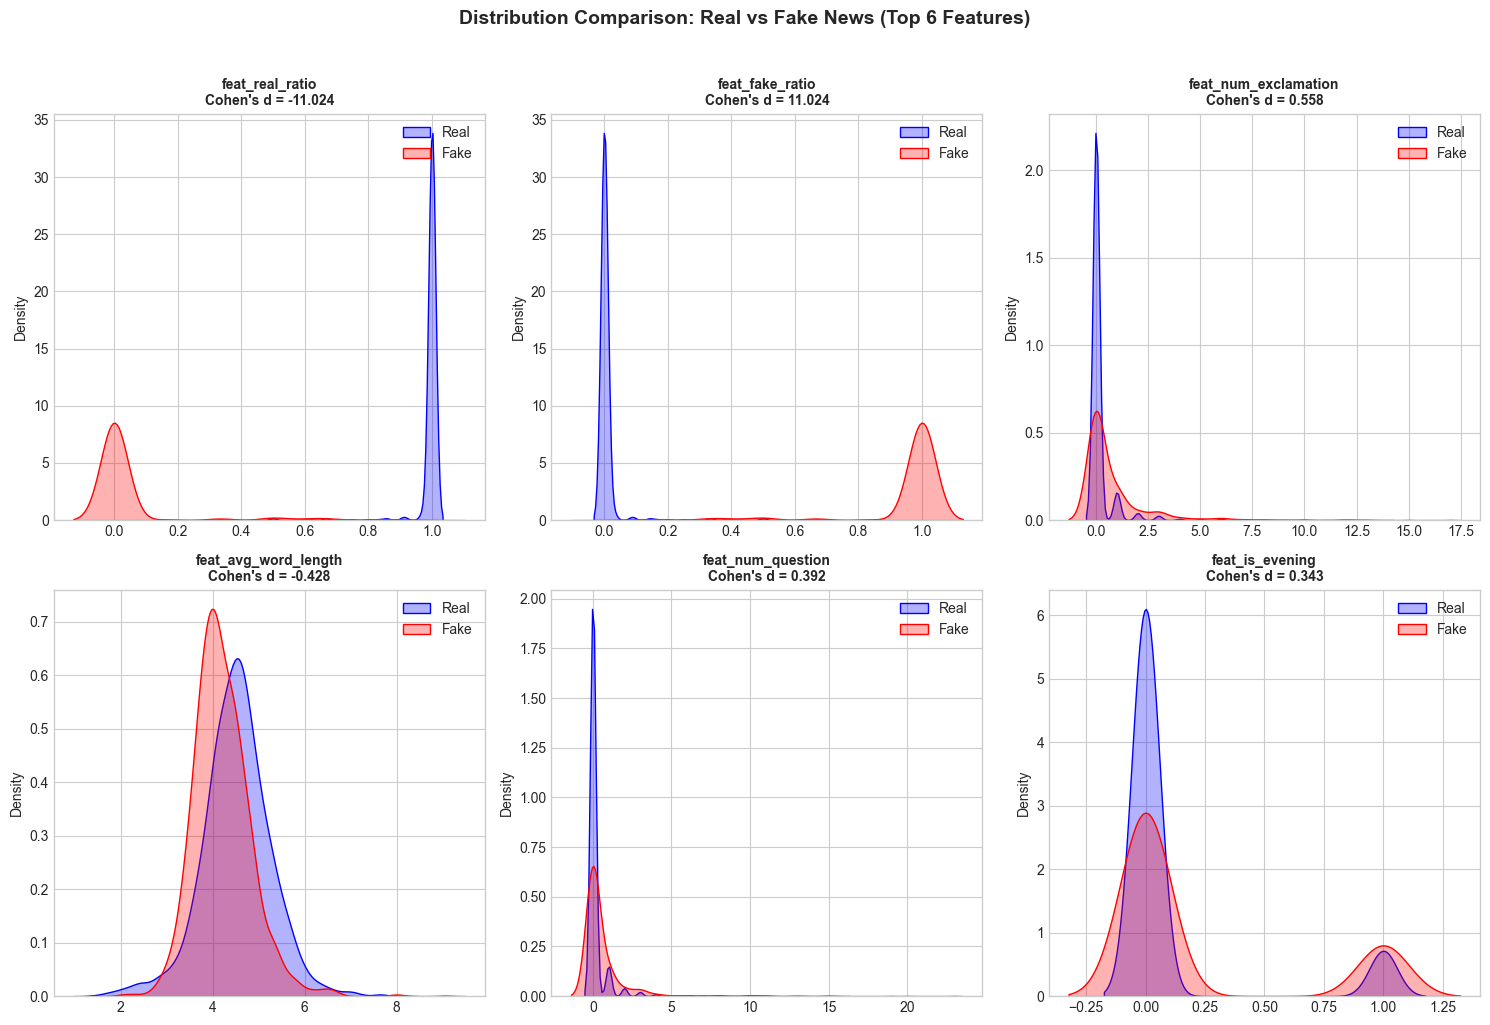


✓ Saved: figures/top_features_distribution.png


In [54]:
# Top 6 features by Cohen's d
top_features = results_df.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feat in enumerate(top_features):
    ax = axes[idx]
    
    # KDE plot
    sns.kdeplot(data=df_real[feat], ax=ax, label='Real', color='blue', fill=True, alpha=0.3)
    sns.kdeplot(data=df_fake[feat], ax=ax, label='Fake', color='red', fill=True, alpha=0.3)
    
    # Get Cohen's d for this feature
    d = results_df[results_df['feature'] == feat]['cohens_d'].values[0]
    
    ax.set_title(f"{feat}\nCohen's d = {d:.3f}", fontsize=10, fontweight='bold')
    ax.legend()
    ax.set_xlabel('')

plt.suptitle("Distribution Comparison: Real vs Fake News (Top 6 Features)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'top_features_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: figures/top_features_distribution.png")

### 4.4 Boxplots for Top Features

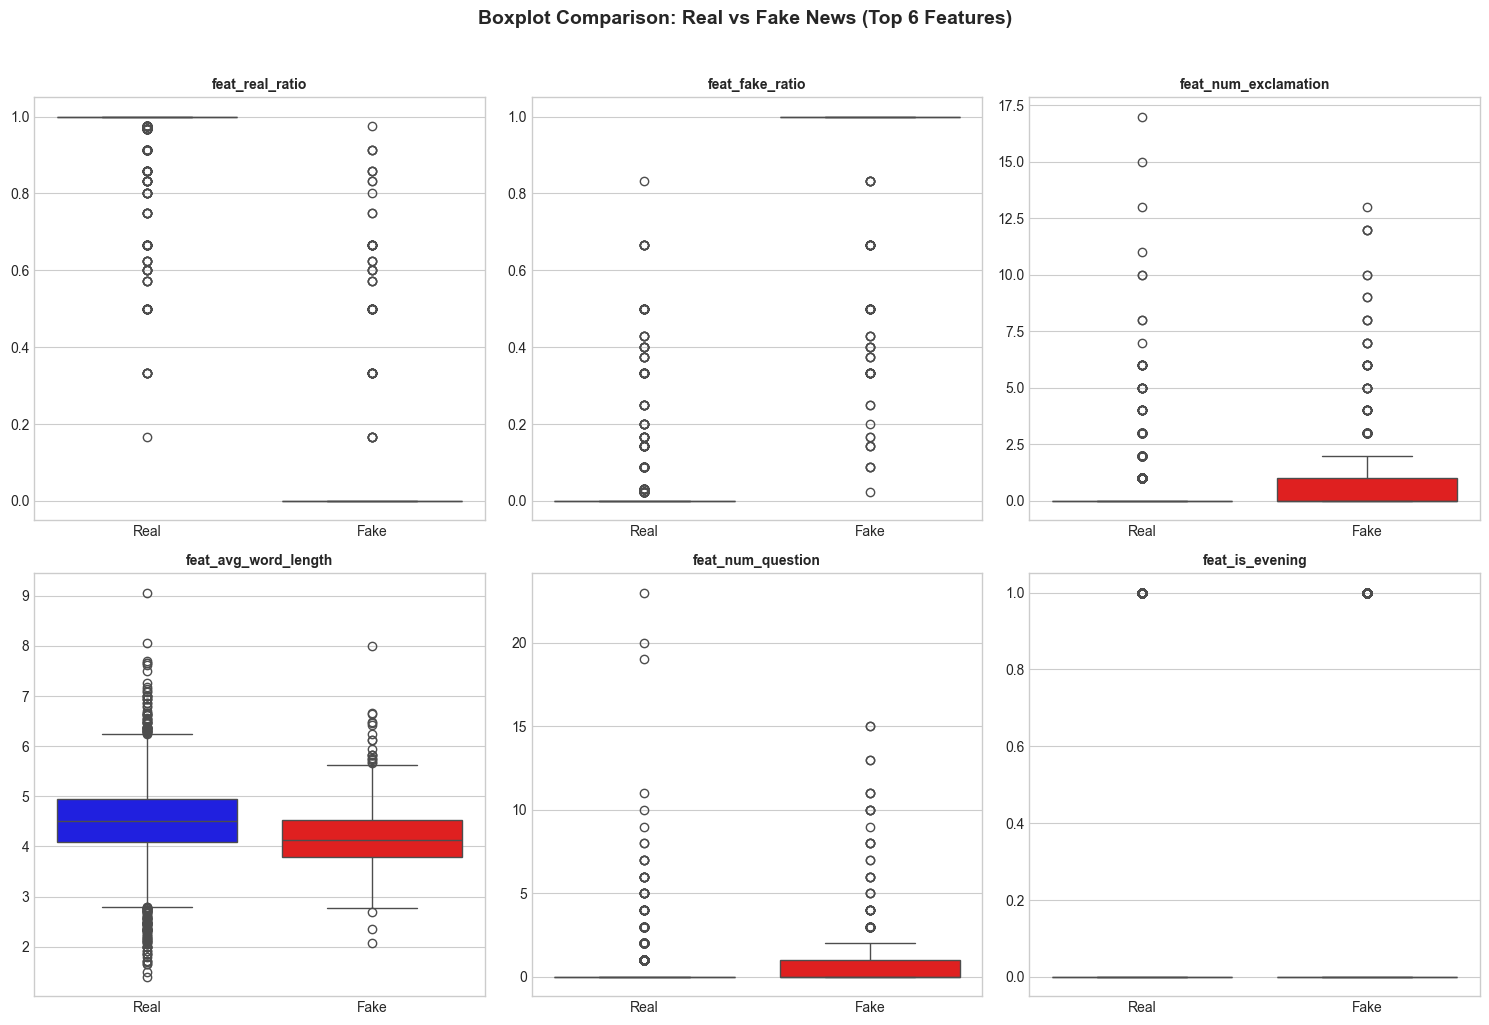


✓ Saved: figures/top_features_boxplot.png


In [55]:
# Boxplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feat in enumerate(top_features):
    ax = axes[idx]
    
    # Prepare data
    plot_data = pd.DataFrame({
        'value': df[feat],
        'label': df['label'].map({0: 'Real', 1: 'Fake'})
    })
    
    # Boxplot
    sns.boxplot(data=plot_data, x='label', y='value', ax=ax, palette=['blue', 'red'])
    
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle("Boxplot Comparison: Real vs Fake News (Top 6 Features)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'top_features_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: figures/top_features_boxplot.png")

### 4.5 Correlation Heatmap

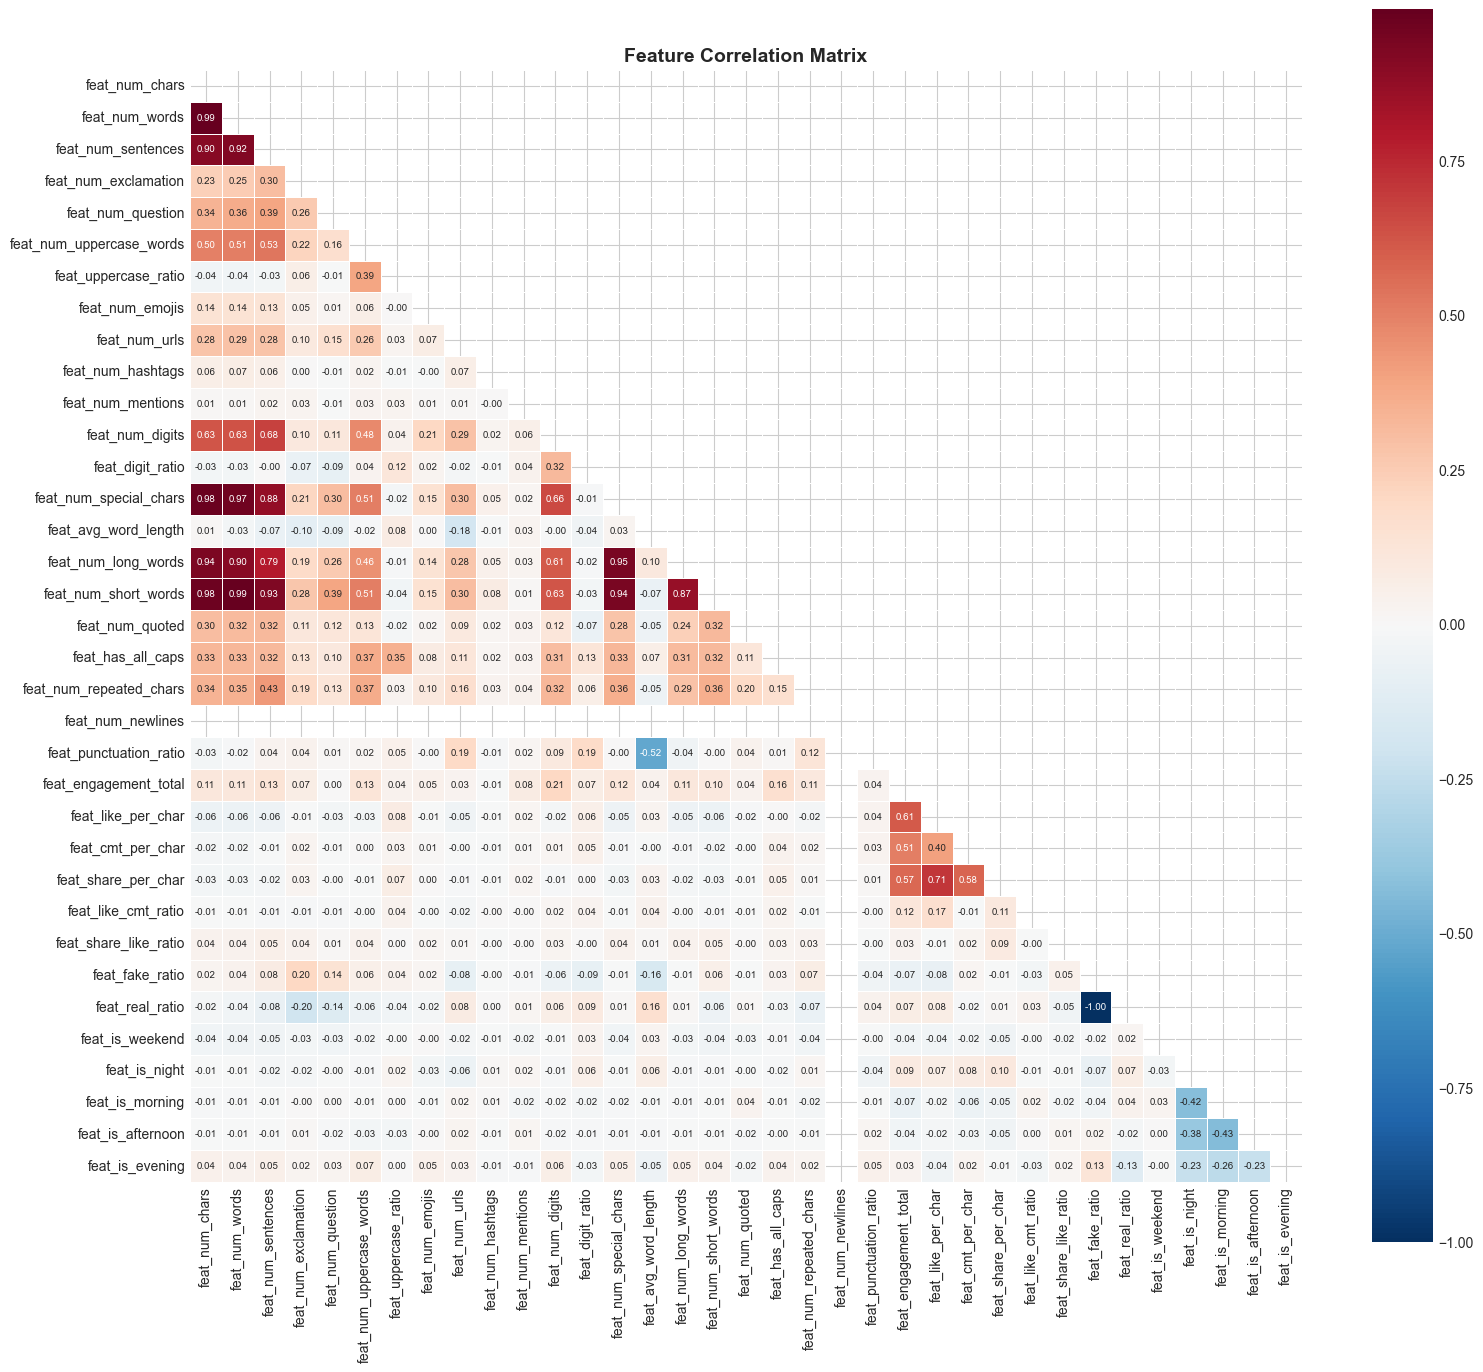


✓ Saved: figures/feature_correlation_heatmap.png


In [56]:
# Correlation matrix
corr_matrix = df[numeric_features].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(16, 14))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5,
            annot_kws={'size': 7})

ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: figures/feature_correlation_heatmap.png")

## 5. Feature Selection

In [57]:
# Selection criteria
COHENS_D_THRESHOLD = 0.2  # Minimum |Cohen's d|
P_VALUE_THRESHOLD = 0.05  # Maximum p-value (significance)
CORRELATION_THRESHOLD = 0.9  # Remove highly correlated features

print("Selection Criteria:")
print(f"  - |Cohen's d| >= {COHENS_D_THRESHOLD}")
print(f"  - p-value < {P_VALUE_THRESHOLD}")
print(f"  - Correlation < {CORRELATION_THRESHOLD}")

Selection Criteria:
  - |Cohen's d| >= 0.2
  - p-value < 0.05
  - Correlation < 0.9


In [58]:
# Step 1: Filter by Cohen's d and p-value
selected_df = results_df[
    (results_df['cohens_d_abs'] >= COHENS_D_THRESHOLD) & 
    (results_df['t_pvalue'] < P_VALUE_THRESHOLD)
].copy()

print(f"After Cohen's d & p-value filter: {len(selected_df)} features")
print("\nSelected features:")
for _, row in selected_df.iterrows():
    print(f"  - {row['feature']}: d={row['cohens_d']:.3f} ({row['cohens_d_interp']}), p={row['t_pvalue']:.2e}")

After Cohen's d & p-value filter: 9 features

Selected features:
  - feat_real_ratio: d=-11.024 (large), p=0.00e+00
  - feat_fake_ratio: d=11.024 (large), p=0.00e+00
  - feat_num_exclamation: d=0.558 (medium), p=1.95e-20
  - feat_avg_word_length: d=-0.428 (small), p=1.11e-34
  - feat_num_question: d=0.392 (small), p=1.48e-11
  - feat_is_evening: d=0.343 (small), p=5.41e-13
  - feat_num_urls: d=-0.231 (small), p=2.10e-12
  - feat_digit_ratio: d=-0.225 (small), p=1.38e-10
  - feat_num_sentences: d=0.208 (small), p=4.40e-07


In [59]:
# Step 2: Remove highly correlated features
selected_features = selected_df['feature'].tolist()

# Get correlation matrix for selected features
selected_corr = df[selected_features].corr().abs()

# Find pairs with high correlation
high_corr_pairs = []
for i in range(len(selected_features)):
    for j in range(i+1, len(selected_features)):
        if selected_corr.iloc[i, j] >= CORRELATION_THRESHOLD:
            feat_i = selected_features[i]
            feat_j = selected_features[j]
            corr_val = selected_corr.iloc[i, j]
            high_corr_pairs.append((feat_i, feat_j, corr_val))

print(f"\nHighly correlated pairs (r >= {CORRELATION_THRESHOLD}):")
if high_corr_pairs:
    for f1, f2, r in high_corr_pairs:
        print(f"  - {f1} <-> {f2}: r={r:.3f}")
else:
    print("  None found")


Highly correlated pairs (r >= 0.9):
  - feat_real_ratio <-> feat_fake_ratio: r=1.000


In [60]:
# Remove one from each highly correlated pair (keep the one with higher Cohen's d)
features_to_remove = set()

for f1, f2, _ in high_corr_pairs:
    d1 = results_df[results_df['feature'] == f1]['cohens_d_abs'].values[0]
    d2 = results_df[results_df['feature'] == f2]['cohens_d_abs'].values[0]
    
    if d1 >= d2:
        features_to_remove.add(f2)
        print(f"Removing {f2} (d={d2:.3f}), keeping {f1} (d={d1:.3f})")
    else:
        features_to_remove.add(f1)
        print(f"Removing {f1} (d={d1:.3f}), keeping {f2} (d={d2:.3f})")

# Final selected features
final_features = [f for f in selected_features if f not in features_to_remove]

print(f"\n{'='*60}")
print(f"FINAL SELECTED FEATURES: {len(final_features)}")
print(f"{'='*60}")
for i, feat in enumerate(final_features, 1):
    d = results_df[results_df['feature'] == feat]['cohens_d'].values[0]
    interp = results_df[results_df['feature'] == feat]['cohens_d_interp'].values[0]
    print(f"  {i}. {feat}: d={d:.3f} ({interp})")

Removing feat_fake_ratio (d=11.024), keeping feat_real_ratio (d=11.024)

FINAL SELECTED FEATURES: 8
  1. feat_real_ratio: d=-11.024 (large)
  2. feat_num_exclamation: d=0.558 (medium)
  3. feat_avg_word_length: d=-0.428 (small)
  4. feat_num_question: d=0.392 (small)
  5. feat_is_evening: d=0.343 (small)
  6. feat_num_urls: d=-0.231 (small)
  7. feat_digit_ratio: d=-0.225 (small)
  8. feat_num_sentences: d=0.208 (small)


## 6. Create Final Dataset

In [61]:
# Columns to keep in final dataset
essential_cols = ['id', 'label', 'text_tfidf', 'text_bert']  # ID, label, cleaned texts

# Add selected features
final_cols = essential_cols + final_features

# Check which columns exist
existing_cols = [c for c in final_cols if c in df.columns]
missing_cols = [c for c in final_cols if c not in df.columns]

if missing_cols:
    print(f"Warning: Missing columns: {missing_cols}")

print(f"\nFinal dataset columns ({len(existing_cols)}):")
for col in existing_cols:
    print(f"  - {col}")


Final dataset columns (12):
  - id
  - label
  - text_tfidf
  - text_bert
  - feat_real_ratio
  - feat_num_exclamation
  - feat_avg_word_length
  - feat_num_question
  - feat_is_evening
  - feat_num_urls
  - feat_digit_ratio
  - feat_num_sentences


In [62]:
# Create final dataset
df_final = df[existing_cols].copy()

print(f"\nFinal dataset shape: {df_final.shape}")
print(f"\nColumn types:")
print(df_final.dtypes)


Final dataset shape: (4736, 12)

Column types:
id                        int64
label                     int64
text_tfidf               object
text_bert                object
feat_real_ratio         float64
feat_num_exclamation      int64
feat_avg_word_length    float64
feat_num_question         int64
feat_is_evening           int64
feat_num_urls             int64
feat_digit_ratio        float64
feat_num_sentences        int64
dtype: object


In [63]:
# Save final dataset
output_file = OUTPUT_DATA_DIR / "02_final.csv"
df_final.to_csv(output_file, index=False)

print(f"\n✓ Saved final dataset to: {output_file}")
print(f"  - Rows: {len(df_final)}")
print(f"  - Columns: {len(df_final.columns)}")


✓ Saved final dataset to: ..\..\data\processed\02_final.csv
  - Rows: 4736
  - Columns: 12


In [64]:
# Save feature statistics
stats_file = OUTPUT_ANALYSIS_DIR / "feature_statistics.csv"
results_df.to_csv(stats_file, index=False)

print(f"\n✓ Saved feature statistics to: {stats_file}")


✓ Saved feature statistics to: ..\..\data\analysis\feature_statistics.csv


In [65]:
# Save selected features list
selected_features_file = OUTPUT_ANALYSIS_DIR / "selected_features.txt"
with open(selected_features_file, 'w') as f:
    f.write("# Selected Features for Training\n")
    f.write(f"# Selection Criteria: |Cohen's d| >= {COHENS_D_THRESHOLD}, p < {P_VALUE_THRESHOLD}\n")
    f.write(f"# Total: {len(final_features)} features\n\n")
    for feat in final_features:
        d = results_df[results_df['feature'] == feat]['cohens_d'].values[0]
        f.write(f"{feat}\t{d:.4f}\n")

print(f"\n✓ Saved selected features list to: {selected_features_file}")


✓ Saved selected features list to: ..\..\data\analysis\selected_features.txt


## 7. Summary

In [66]:
print("="*60)
print("FEATURE ANALYSIS SUMMARY")
print("="*60)

print(f"\n📊 Total features analyzed: {len(numeric_features)}")

# Count by effect size
large_effect = len(results_df[results_df['cohens_d_interp'] == 'large'])
medium_effect = len(results_df[results_df['cohens_d_interp'] == 'medium'])
small_effect = len(results_df[results_df['cohens_d_interp'] == 'small'])
negligible_effect = len(results_df[results_df['cohens_d_interp'] == 'negligible'])

print(f"\n📈 Effect sizes:")
print(f"  - Large (d >= 0.8):     {large_effect}")
print(f"  - Medium (0.5-0.8):     {medium_effect}")
print(f"  - Small (0.2-0.5):      {small_effect}")
print(f"  - Negligible (< 0.2):   {negligible_effect}")

print(f"\n✅ Final selected features: {len(final_features)}")

print(f"\n📁 Output files:")
print(f"  data/processed/")
print(f"    └── 02_final.csv")
print(f"  data/analysis/")
print(f"    ├── feature_statistics.csv")
print(f"    └── selected_features.txt")
print(f"  data/figures/")
print(f"    ├── cohens_d_chart.png")
print(f"    ├── ks_vs_cohens_d.png")
print(f"    ├── top_features_distribution.png")
print(f"    ├── top_features_boxplot.png")
print(f"    └── feature_correlation_heatmap.png")

print("\n" + "="*60)

FEATURE ANALYSIS SUMMARY

📊 Total features analyzed: 35

📈 Effect sizes:
  - Large (d >= 0.8):     2
  - Medium (0.5-0.8):     1
  - Small (0.2-0.5):      6
  - Negligible (< 0.2):   26

✅ Final selected features: 8

📁 Output files:
  data/processed/
    └── 02_final.csv
  data/analysis/
    ├── feature_statistics.csv
    └── selected_features.txt
  data/figures/
    ├── cohens_d_chart.png
    ├── ks_vs_cohens_d.png
    ├── top_features_distribution.png
    ├── top_features_boxplot.png
    └── feature_correlation_heatmap.png

